# Manufacturing Quotes — Exploración para Clustering de Forma

**Objetivo:** clusterizar piezas por **forma geométrica únicamente** (sin tamaño). En una segunda fase se sub-categorizará por tamaño dentro de cada familia de forma.

**Decisión clave:** las features de clustering deben ser *dimensionless* (independientes de escala). Eso implica:
- Excluir: `part_volume_cm3`, `weight_g`, `stock_volume_cm3`, `bounding_box` absoluto, `stock_dimensions`, `total_holes` (crece con tamaño), `max_hole_depth_mm`.
- Derivar: `bounding_box` → proporciones x/L, y/L, z/L (L=max dim). `face_orientation_distribution` → porcentajes (dividir por suma).
- Mantener: ratios de forma ya dimensionless (`aspect_ratio`, `thin_ratio`, `plane_ratio`, `cyl_ratio`, `complex_ratio`, `material_removal_pct`), conteos de accesibilidad (`direction_count`, `min_setups_3axis`, `undercut_count`, `angled_hole_count`, `inaccessible_feature_count`), categóricas (`part_type`, `axis_recommendation`).

**Pasos:**
1. Cargar y normalizar columnas
2. Análisis de nulos → filtrar a filas con DFM
3. Feature engineering: construir el shape-only feature set
4. Distribuciones de features de forma
5. Categóricas
6. Distribución de tamaño y precio (contexto — no para clustering)
7. Correlaciones entre features de forma (redundancia)
8. Correlación features de forma ↔ precio (sanity check)
9. Guardar dataset limpio con shape-features derivados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

CSV_PATH = 'manufacturing_quotes_data.csv'

## 1. Cargar y normalizar columnas

In [3]:
df = pd.read_csv(CSV_PATH, skipinitialspace=True)
df.columns = df.columns.str.strip()
print(f'Shape: {df.shape}')
print(f'Columnas ({len(df.columns)}):')
for c in df.columns:
    print(f'  {c}')

Shape: (586, 91)
Columnas (91):
  manufacturing_quote_id
  manufacturing_quote_created_at
  line_item_id
  radii_id
  source_type
  product_name
  actual_partner_quoted_price
  actual_partner_quoted_quantity
  partner_id
  partner_name
  partner_country
  quote_is_awarded
  part_volume_cm3
  weight_g
  stock_volume_cm3
  removed_volume_cm3
  material_removal_pct
  stock_dimensions_mm.x
  stock_dimensions_mm.y
  stock_dimensions_mm.z
  faces_qty
  aspect_ratio
  thin_ratio
  plane_ratio
  cyl_ratio
  complex_ratio
  total_holes
  machining_hours
  programming_hours
  num_setups
  setup_hours
  setup_time_per_setup
  roughing_hours
  finishing_hours
  material_dependent_hours
  effective_hourly_rate
  complexity_factor
  mesh_complexity_penalty
  complexity_risk_mult
  total_risk_mult
  tolerance_tier
  tolerance_tier_mult
  tolerance_risk_mult
  axis_requirement
  edm_required
  part_type
  material_cost
  machining_cost
  feature_cost
  finishing_cost
  heat_treatment_cost
  post_produ

In [4]:
df.head(3)

,manufacturing_quote_id,manufacturing_quote_created_at,line_item_id,radii_id,source_type,product_name,actual_partner_quoted_price,actual_partner_quoted_quantity,partner_id,partner_name,partner_country,quote_is_awarded,part_volume_cm3,weight_g,stock_volume_cm3,removed_volume_cm3,material_removal_pct,stock_dimensions_mm.x,stock_dimensions_mm.y,stock_dimensions_mm.z,faces_qty,aspect_ratio,thin_ratio,plane_ratio,cyl_ratio,complex_ratio,total_holes,machining_hours,programming_hours,num_setups,setup_hours,setup_time_per_setup,roughing_hours,finishing_hours,material_dependent_hours,effective_hourly_rate,complexity_factor,mesh_complexity_penalty,complexity_risk_mult,total_risk_mult,tolerance_tier,tolerance_tier_mult,tolerance_risk_mult,axis_requirement,edm_required,part_type,material_cost,machining_cost,feature_cost,finishing_cost,heat_treatment_cost,post_production_cost,overhead,total_cost_floor,quantity,material_nesting_factor,machining_batch_factor,overhead_batch_factor,feature_machining_hours,tool_change_hours,amortized_fixed_hours,material_title,technology,tolerance,finishing,heat_treatment,is_manufacturable,errors_count,warnings_count,summary.critical,summary.medium,summary.low,summary.high,direction_count,min_setups_3axis,setup_complexity,undercut_count,angled_hole_count,inaccessible_feature_count,axis_recommendation,face_orientation_distribution.X+,face_orientation_distribution.X-,face_orientation_distribution.Y+,face_orientation_distribution.Y-,face_orientation_distribution.Z+,face_orientation_distribution.Z-,metadata.tolerance_mm,metadata.max_hole_depth_mm,metadata.bounding_box_mm.x,metadata.bounding_box_mm.y,metadata.bounding_box_mm.z
0,63db48db-d11b-4be4-8802-650d49c3dfbb,2026-04-13T22:30:02.338270+00:00,4781,RAD-6222,rfq,EDM_V-10033460AC-000020-001_000_00_prt ...,1726.7908,1.0,1.0,Tecnomaquinados,SJR,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,steel_grade_A2,CNC,4,smooth_machining,False,False,8.0,0.0,0.0,0.0,0.0,8.0,3.0,3.0,1.6,0.0,0.0,0.0,3-axis,4.0,0.0,4.0,0.0,2.0,0.0,0.01,70.0,325.000000,250.000000,70.000000
1,83ff41cf-cdea-4e70-ba0d-2261eb2133e2,2026-04-03T19:58:44.623762+00:00,4673,RAD-6197,rfq,V-10033460AC-P00005-013_000_AA ...,648.9952,2.0,134.0,JISA Mecánica Técnica,MX,True,3761.32,29526.38,10077.50,6316.18,62.7,552.5,152.4,50.8,139.0,1.00,0.000,0.266,0.734,0.000,51.0,1.80,0.00,1.0,0.75,0.75,0.000,0.000,1.422,25.061645,1.00,1.25,1.12,1.1962,tight,1.068,1.068,3-axis,False,rotational,142.218027,45.046061,0.0,89.660425,0.000000,67.343103,2.868327,441.316736,2,1.62,1.0,1.41,0.00,0.000,0.375,other,CNC,0,smooth_machining,False,True,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,1.8,0.0,0.0,0.0,3-axis,8.0,0.0,2.0,0.0,23.0,0.0,0.01,50.8,533.400024,152.399994,50.799999
2,1bf3f041-6d6d-4c3a-86af-015393c41540,2026-04-03T19:58:44.582838+00:00,4674,RAD-6197,rfq,V-10033460AC-T00725-009_000_00 ...,8019.7264,1.0,134.0,JISA Mecánica Técnica,MX,True,4954.15,38890.08,19578.44,14624.29,74.7,76.2,374.6,685.8,106.0,8.82,0.113,0.217,0.689,0.019,30.0,60.49,0.62,3.0,1.80,0.60,43.943,10.235,58.062,35.086303,1.01,1.25,1.05,1.1214,tight,1.068,1.068,3-axis,False,rotational,1963.721564,2122.260081,0.0,117.510432,157.746975,516.450099,31.870300,5958.662510,1,1.00,1.0,1.00,3.75,0.133,2.425,steel_grade_A2,CNC,0,smooth_machining,True,True,0.0,16.0,0.0,16.0,0.0,0.0,3.0,3.0,2.4,0.0,4.0,0.0,5-axis,15.0,0.0,4.0,0.0,4.0,0.0,0.01,76.2,76.199997,369.992096,672.000000


## 2. Análisis de nulos → filtrar a filas con DFM

In [5]:
null_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print('% de nulos por columna:')
print(null_pct.to_string())

% de nulos por columna:
part_type                           49.488055
faces_qty                           49.317406
aspect_ratio                        49.317406
stock_dimensions_mm.z               49.317406
stock_dimensions_mm.y               49.317406
material_removal_pct                49.317406
stock_dimensions_mm.x               49.317406
removed_volume_cm3                  49.317406
stock_volume_cm3                    49.317406
weight_g                            49.317406
plane_ratio                         49.317406
complex_ratio                       49.317406
cyl_ratio                           49.317406
thin_ratio                          49.317406
total_risk_mult                     49.317406
complexity_risk_mult                49.317406
mesh_complexity_penalty             49.317406
complexity_factor                   49.317406
effective_hourly_rate               49.317406
setup_hours                         49.317406
finishing_hours                     49.317406
roughing_h

In [8]:
has_dfm = df['part_volume_cm3'].notna()
print(f'Filas con DFM: {has_dfm.sum()} / {len(df)} ({has_dfm.mean()*100:.1f}%)')

df_dfm = df[has_dfm].copy().reset_index(drop=True)
print(f'Dataset filtrado: {df_dfm.shape}')

null_pct_dfm = (df_dfm.isna().sum() / len(df_dfm) * 100).sort_values(ascending=False)
print('\nColumnas con nulos remanentes:')
print(null_pct_dfm[null_pct_dfm > 0].to_string())

Filas con DFM: 297 / 586 (50.7%)
Dataset filtrado: (297, 91)

Columnas con nulos remanentes:
face_orientation_distribution.Z-    3.367003
face_orientation_distribution.Z+    3.367003
face_orientation_distribution.Y-    3.367003
face_orientation_distribution.Y+    3.367003
face_orientation_distribution.X-    3.367003
face_orientation_distribution.X+    3.367003
axis_recommendation                 3.367003
inaccessible_feature_count          3.367003
angled_hole_count                   3.367003
min_setups_3axis                    3.367003
direction_count                     3.367003
metadata.bounding_box_mm.y          3.367003
metadata.bounding_box_mm.z          3.367003
metadata.bounding_box_mm.x          3.367003
metadata.max_hole_depth_mm          3.367003
metadata.tolerance_mm               3.367003
setup_complexity                    3.367003
undercut_count                      3.367003
actual_partner_quoted_quantity      0.336700
part_type                           0.336700


## 3. Feature engineering — shape-only feature set

Construimos features *dimensionless* a partir del dataset filtrado. Todas capturan **forma** sin depender del tamaño absoluto.

In [9]:
# 3.1 Bounding box → proporciones (dividimos cada dim por la más grande)
bbox_cols = ['metadata.bounding_box_mm.x', 'metadata.bounding_box_mm.y', 'metadata.bounding_box_mm.z']
bbox = df_dfm[bbox_cols].values
bbox_max = bbox.max(axis=1, keepdims=True)
# Evitamos /0
bbox_max = np.where(bbox_max == 0, 1, bbox_max)
bbox_ratios = bbox / bbox_max
# Ordenamos descendente para que bbox_ratio_1 >= bbox_ratio_2 >= bbox_ratio_3 (invariante a rotación)
bbox_ratios_sorted = -np.sort(-bbox_ratios, axis=1)
df_dfm['bbox_ratio_1'] = bbox_ratios_sorted[:, 0]  # siempre 1.0 (máxima dim)
df_dfm['bbox_ratio_2'] = bbox_ratios_sorted[:, 1]  # segunda más grande / máxima
df_dfm['bbox_ratio_3'] = bbox_ratios_sorted[:, 2]  # más pequeña / máxima
print('bbox_ratio_1 (debería ser siempre 1.0):', df_dfm['bbox_ratio_1'].describe())
print('\nbbox_ratio_2:', df_dfm['bbox_ratio_2'].describe())
print('\nbbox_ratio_3:', df_dfm['bbox_ratio_3'].describe())

bbox_ratio_1 (debería ser siempre 1.0): count    287.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: bbox_ratio_1, dtype: float64

bbox_ratio_2: count    287.000000
mean       0.638526
std        0.301996
min        0.062949
25%        0.362978
50%        0.608247
75%        0.979982
max        1.000000
Name: bbox_ratio_2, dtype: float64

bbox_ratio_3: count    287.000000
mean       0.305024
std        0.218010
min        0.029808
25%        0.141851
50%        0.231884
75%        0.434593
max        0.881780
Name: bbox_ratio_3, dtype: float64


In [10]:
# 3.2 Face orientations → porcentajes
face_cols = [
    'face_orientation_distribution.X+', 'face_orientation_distribution.X-',
    'face_orientation_distribution.Y+', 'face_orientation_distribution.Y-',
    'face_orientation_distribution.Z+', 'face_orientation_distribution.Z-',
]
face_totals = df_dfm[face_cols].sum(axis=1)
# Evitamos /0
face_totals_safe = face_totals.replace(0, 1)
for c in face_cols:
    df_dfm[c + '_pct'] = df_dfm[c] / face_totals_safe
face_pct_cols = [c + '_pct' for c in face_cols]
df_dfm[face_pct_cols].describe()

,face_orientation_distribution.X+_pct,face_orientation_distribution.X-_pct,face_orientation_distribution.Y+_pct,face_orientation_distribution.Y-_pct,face_orientation_distribution.Z+_pct,face_orientation_distribution.Z-_pct
count,287.000000,287.0,287.000000,287.0,287.000000,287.0
mean,0.298679,0.0,0.274039,0.0,0.427282,0.0
std,0.258370,0.0,0.275493,0.0,0.299510,0.0
min,0.000000,0.0,0.000000,0.0,0.000000,0.0
25%,0.027778,0.0,0.000000,0.0,0.250000,0.0
50%,0.312500,0.0,0.250000,0.0,0.350000,0.0
75%,0.384921,0.0,0.333333,0.0,0.625000,0.0
max,1.000000,0.0,1.000000,0.0,1.000000,0.0


In [11]:
# 3.3 Definir los feature sets finales
SHAPE_RATIOS = [
    'aspect_ratio', 'thin_ratio', 'plane_ratio', 'cyl_ratio', 'complex_ratio',
    'material_removal_pct',
]
BBOX_SHAPE = ['bbox_ratio_2', 'bbox_ratio_3']  # bbox_ratio_1 es constante (=1), se descarta
FACE_SHAPE = face_pct_cols
ACCESS_SHAPE = [
    'direction_count', 'min_setups_3axis',
    'undercut_count', 'angled_hole_count', 'inaccessible_feature_count',
]
SHAPE_FEATURES = SHAPE_RATIOS + BBOX_SHAPE + FACE_SHAPE + ACCESS_SHAPE

CATEGORICAL_SHAPE = ['part_type', 'axis_recommendation']

# Size / cost (NO se usan para clustering — contexto y fases futuras)
SIZE_FEATURES = [
    'part_volume_cm3', 'weight_g', 'stock_volume_cm3', 'removed_volume_cm3',
    'metadata.bounding_box_mm.x', 'metadata.bounding_box_mm.y', 'metadata.bounding_box_mm.z',
    'total_holes', 'faces_qty', 'metadata.max_hole_depth_mm',
]

print(f'SHAPE_FEATURES ({len(SHAPE_FEATURES)}):')
for c in SHAPE_FEATURES:
    missing = '❌' if c not in df_dfm.columns else '✓'
    print(f'  {missing} {c}')
print(f'\nCATEGORICAL_SHAPE: {CATEGORICAL_SHAPE}')
print(f'\nSIZE_FEATURES (excluidas del clustering): {len(SIZE_FEATURES)}')

SHAPE_FEATURES (19):
  ✓ aspect_ratio
  ✓ thin_ratio
  ✓ plane_ratio
  ✓ cyl_ratio
  ✓ complex_ratio
  ✓ material_removal_pct
  ✓ bbox_ratio_2
  ✓ bbox_ratio_3
  ✓ face_orientation_distribution.X+_pct
  ✓ face_orientation_distribution.X-_pct
  ✓ face_orientation_distribution.Y+_pct
  ✓ face_orientation_distribution.Y-_pct
  ✓ face_orientation_distribution.Z+_pct
  ✓ face_orientation_distribution.Z-_pct
  ✓ direction_count
  ✓ min_setups_3axis
  ✓ undercut_count
  ✓ angled_hole_count
  ✓ inaccessible_feature_count

CATEGORICAL_SHAPE: ['part_type', 'axis_recommendation']

SIZE_FEATURES (excluidas del clustering): 10


## 4. Distribuciones de features de forma

In [12]:
df_dfm[SHAPE_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
aspect_ratio,297.0,5.961953,5.898037,1.000000,2.250000,4.230000,7.000000,33.55000
thin_ratio,297.0,0.297310,0.221330,0.000000,0.138000,0.222000,0.435000,0.88200
plane_ratio,297.0,0.301202,0.163579,0.000000,0.167000,0.306000,0.407000,0.84600
cyl_ratio,297.0,0.452360,0.167406,0.000000,0.333000,0.464000,0.571000,0.85200
complex_ratio,297.0,0.053774,0.122700,0.000000,0.000000,0.000000,0.028000,0.63500
material_removal_pct,297.0,67.758249,20.147153,0.000000,57.000000,71.900000,83.100000,98.80000
bbox_ratio_2,287.0,0.638526,0.301996,0.062949,0.362978,0.608247,0.979982,1.00000
bbox_ratio_3,287.0,0.305024,0.218010,0.029808,0.141851,0.231884,0.434593,0.88178
face_orientation_distribution.X+_pct,287.0,0.298679,0.258370,0.000000,0.027778,0.312500,0.384921,1.00000
face_orientation_distribution.X-_pct,287.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000


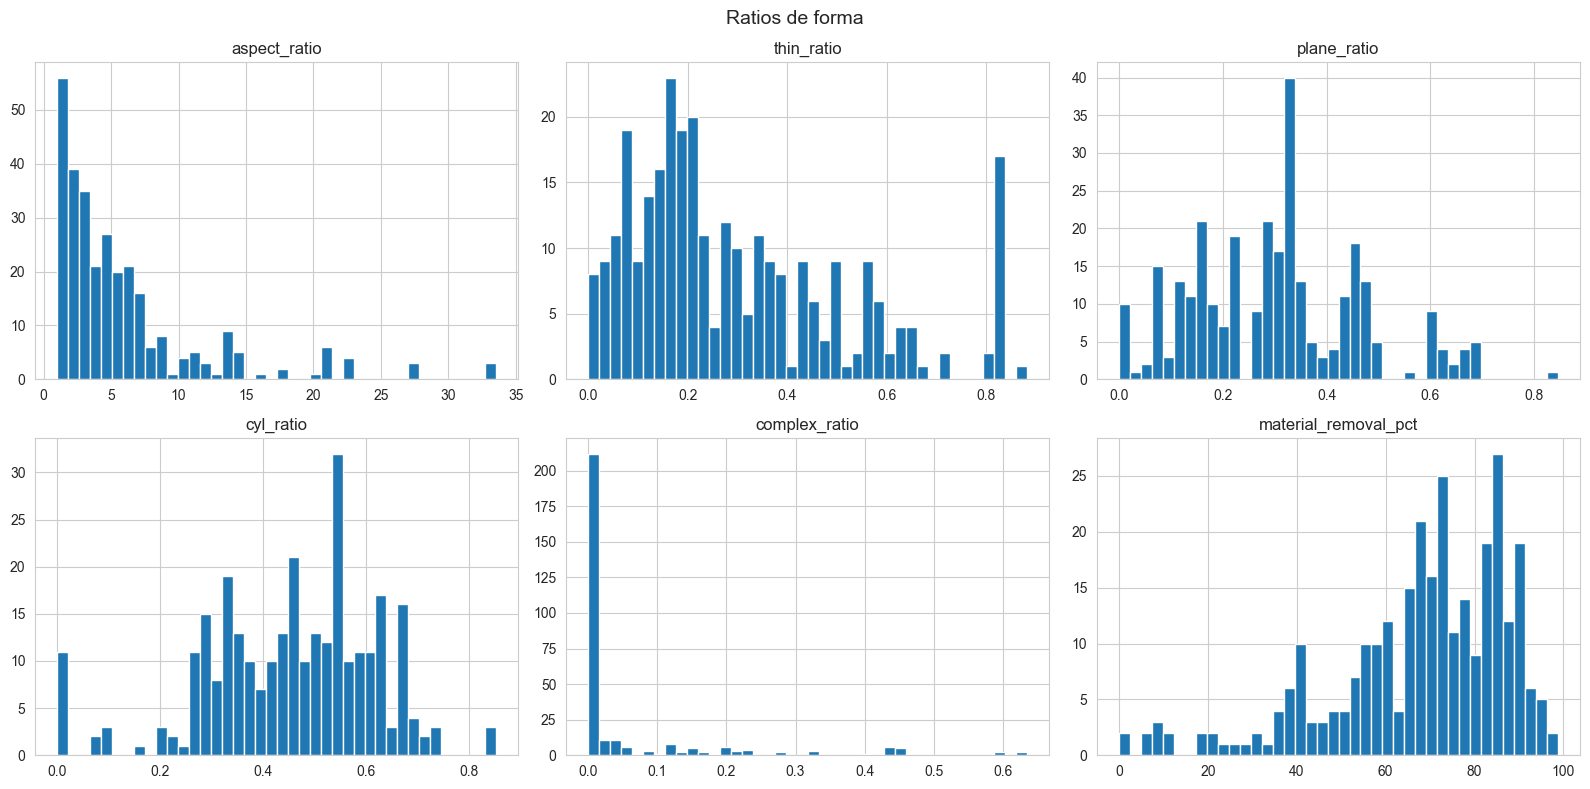

In [13]:
# 4.1 Ratios de forma
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, SHAPE_RATIOS):
    df_dfm[col].hist(bins=40, ax=ax)
    ax.set_title(col)
plt.suptitle('Ratios de forma', fontsize=14)
plt.tight_layout()
plt.show()

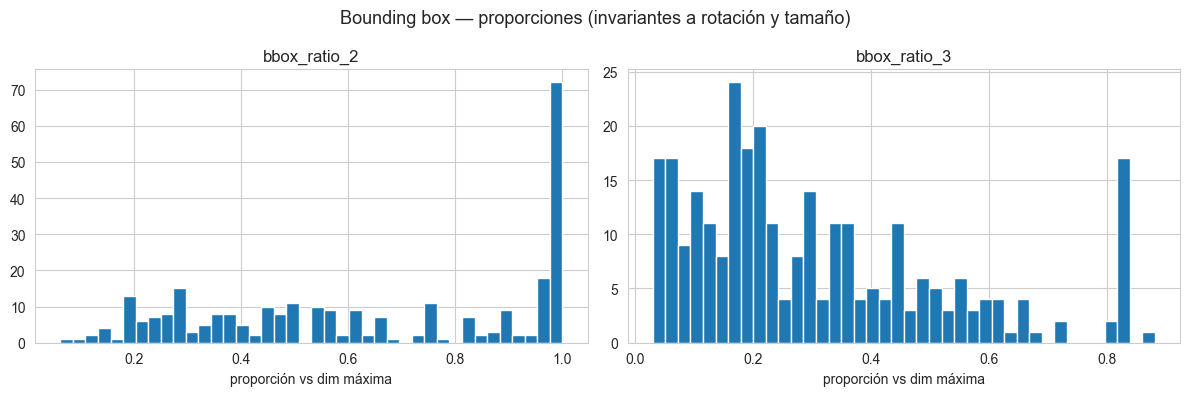

In [14]:
# 4.2 Bounding box — proporciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, BBOX_SHAPE):
    df_dfm[col].hist(bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('proporción vs dim máxima')
plt.suptitle('Bounding box — proporciones (invariantes a rotación y tamaño)', fontsize=13)
plt.tight_layout()
plt.show()

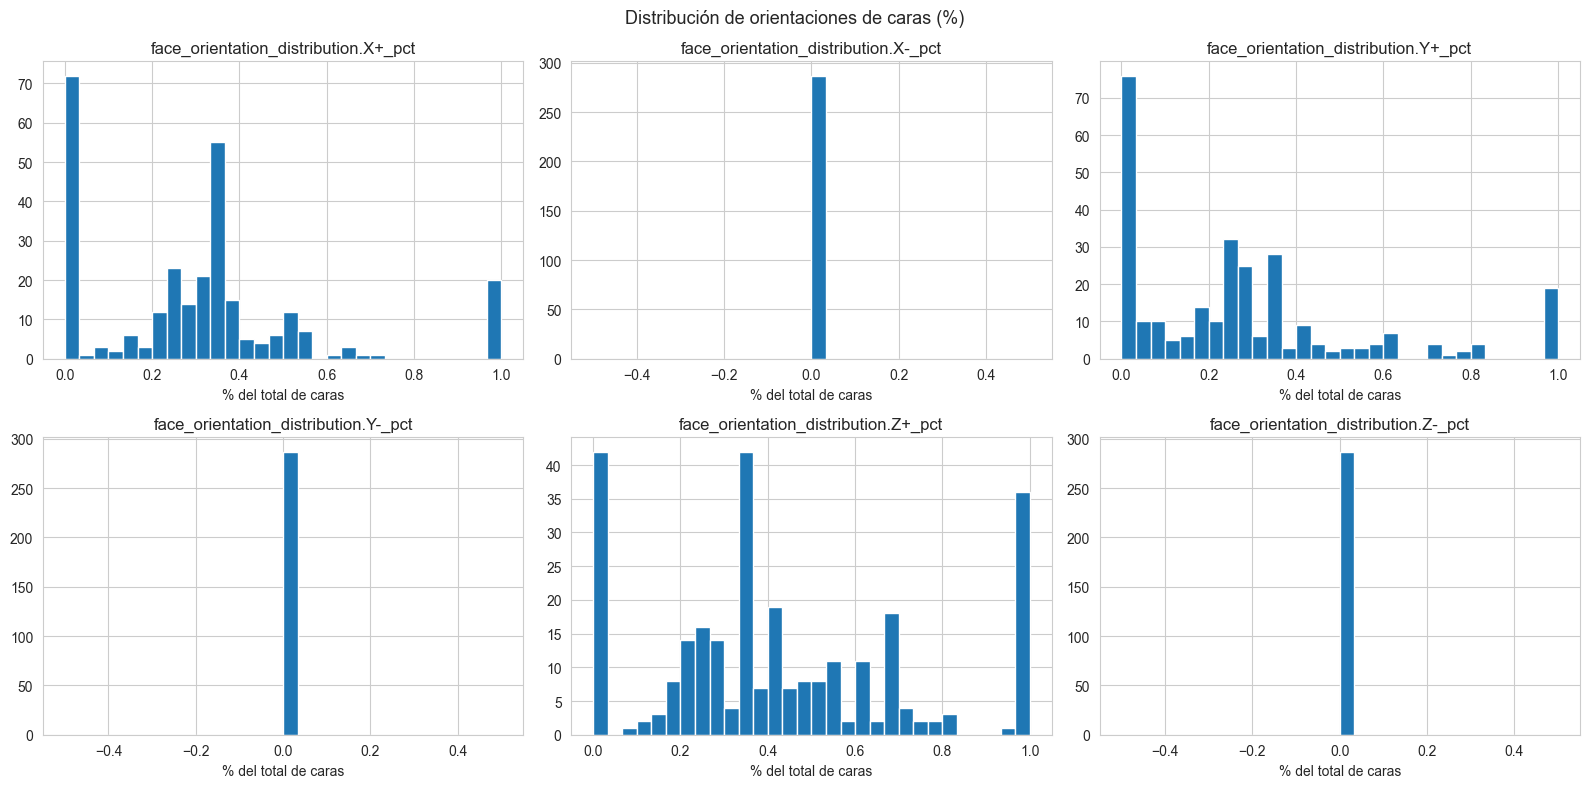

In [15]:
# 4.3 Face orientations (%)
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, FACE_SHAPE):
    df_dfm[col].hist(bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('% del total de caras')
plt.suptitle('Distribución de orientaciones de caras (%)', fontsize=13)
plt.tight_layout()
plt.show()

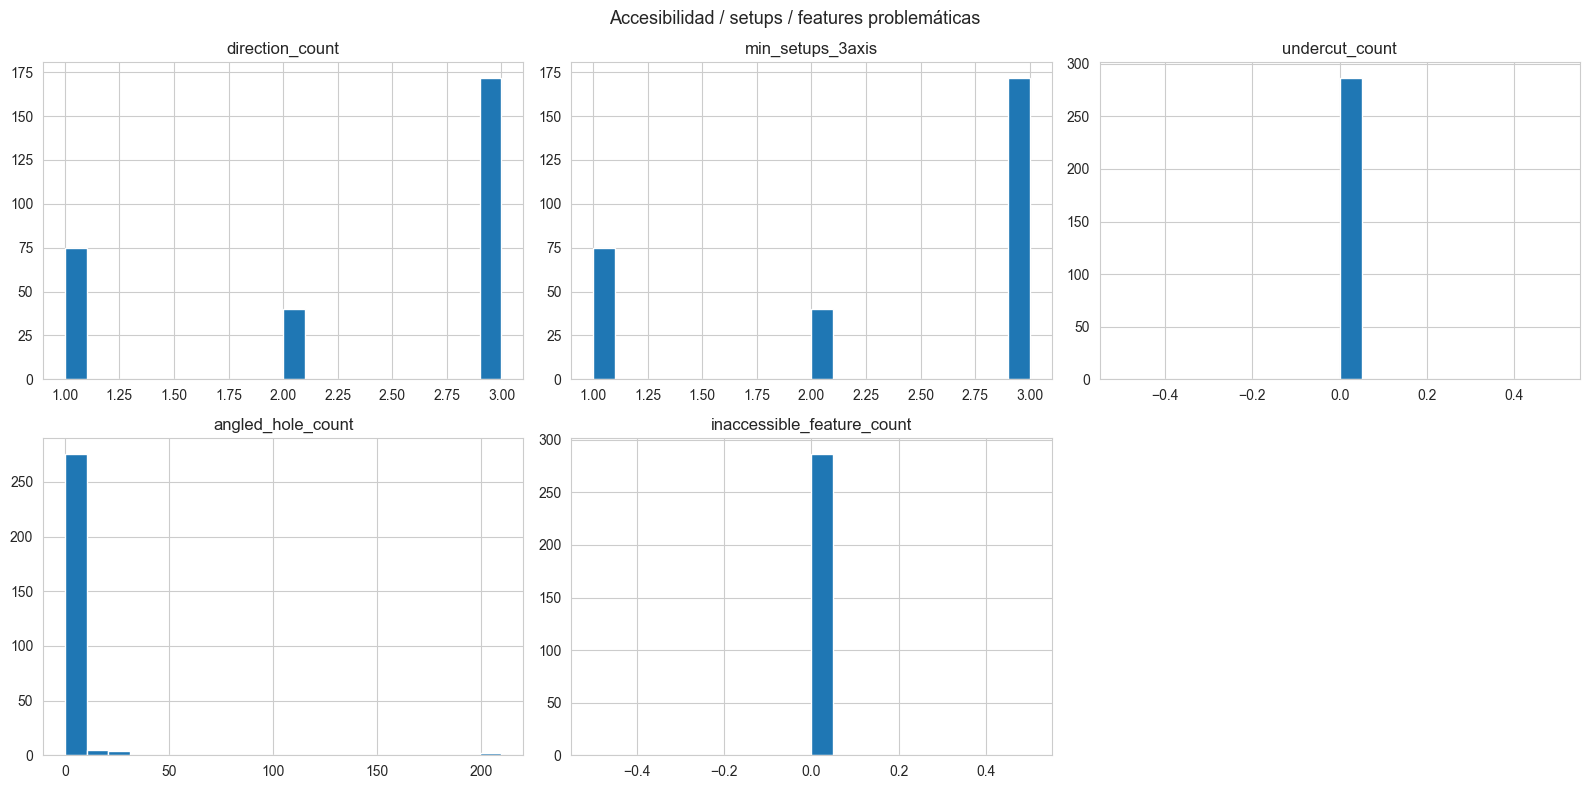

In [16]:
# 4.4 Accesibilidad — conteos enteros pequeños
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, ACCESS_SHAPE):
    df_dfm[col].hist(bins=20, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.suptitle('Accesibilidad / setups / features problemáticas', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Categóricas de forma

In [17]:
for col in CATEGORICAL_SHAPE:
    if col in df_dfm.columns:
        counts = df_dfm[col].value_counts(dropna=False)
        print(f'\n=== {col} ({counts.shape[0]} valores únicos) ===')
        print(counts.head(15).to_string())


=== part_type (5 valores únicos) ===
part_type
rotational    252
complex_3d     29
plate          14
prismatic       1
NaN             1

=== axis_recommendation (4 valores únicos) ===
axis_recommendation
3-axis                 204
5-axis                  82
NaN                     10
4-axis                   1


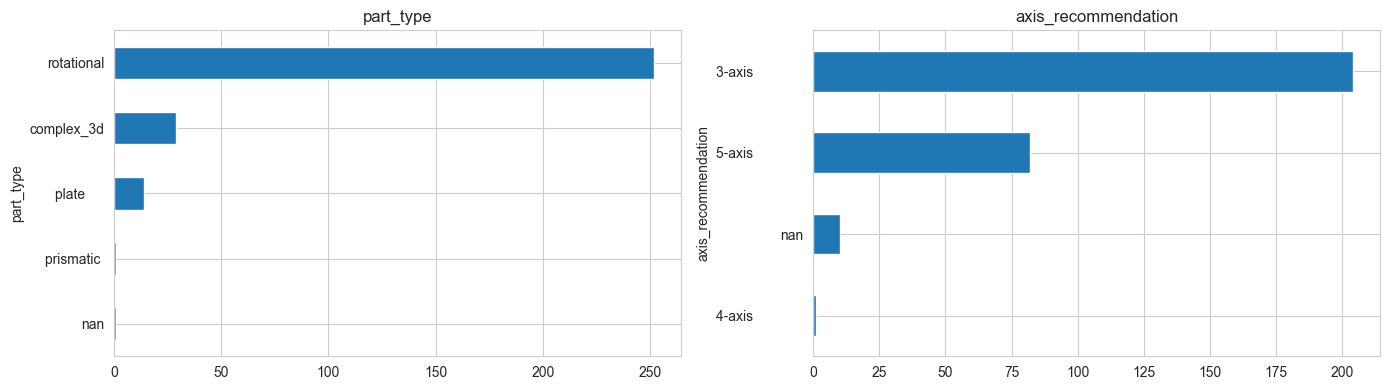

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, CATEGORICAL_SHAPE):
    if col in df_dfm.columns:
        df_dfm[col].value_counts(dropna=False).plot(kind='barh', ax=ax)
        ax.set_title(col)
        ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Tamaño y precio — solo contexto (no entran al clustering)

Los graficamos para tenerlos a la vista cuando en la fase 2 sub-categoricemos por tamaño dentro de cada cluster de forma.

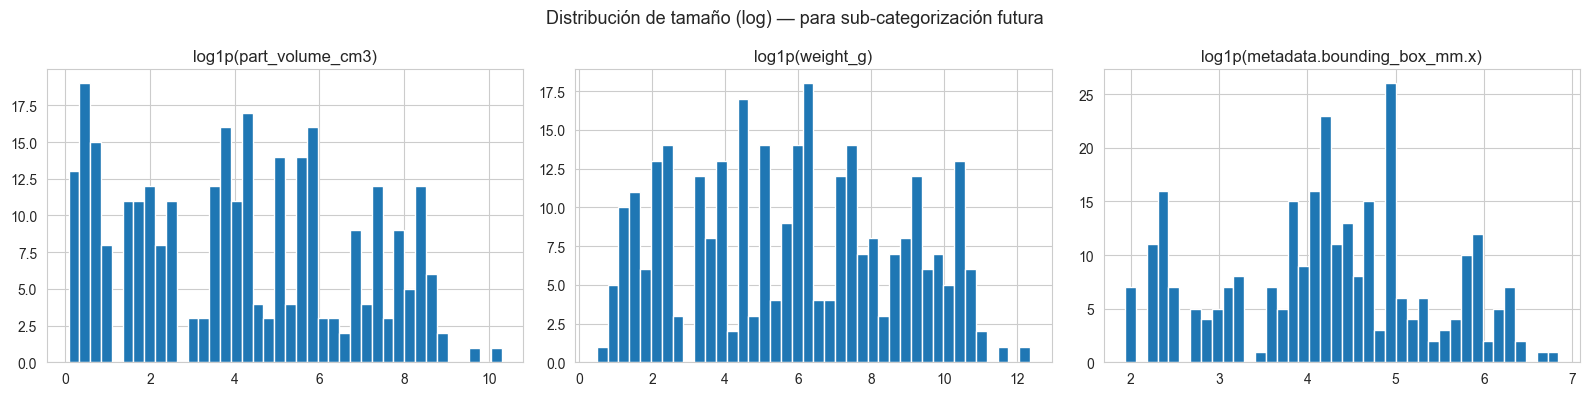

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['part_volume_cm3', 'weight_g', 'metadata.bounding_box_mm.x']):
    np.log1p(df_dfm[col]).hist(bins=40, ax=ax)
    ax.set_title(f'log1p({col})')
plt.suptitle('Distribución de tamaño (log) — para sub-categorización futura', fontsize=13)
plt.tight_layout()
plt.show()

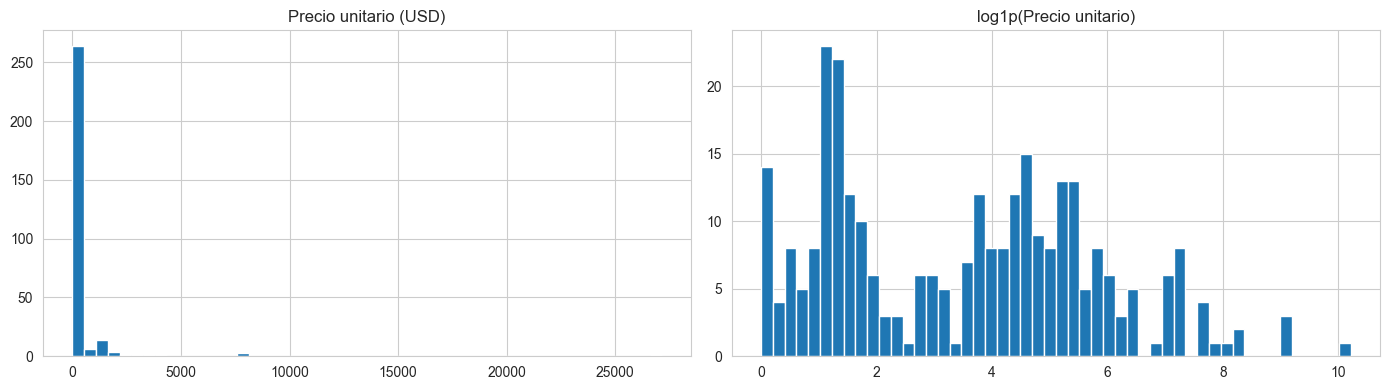

count      296.000000
mean       389.306903
std       1821.905069
min          0.000000
25%          2.919705
50%         41.746100
75%        182.856800
max      27150.279597
Name: unit_price, dtype: float64


In [20]:
df_dfm['unit_price'] = df_dfm['actual_partner_quoted_price'] / df_dfm['actual_partner_quoted_quantity']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_dfm['unit_price'].hist(bins=50, ax=axes[0])
axes[0].set_title('Precio unitario (USD)')
np.log1p(df_dfm['unit_price']).hist(bins=50, ax=axes[1])
axes[1].set_title('log1p(Precio unitario)')
plt.tight_layout()
plt.show()

print(df_dfm['unit_price'].describe())

## 7. Correlaciones entre shape features (detección de redundancia)

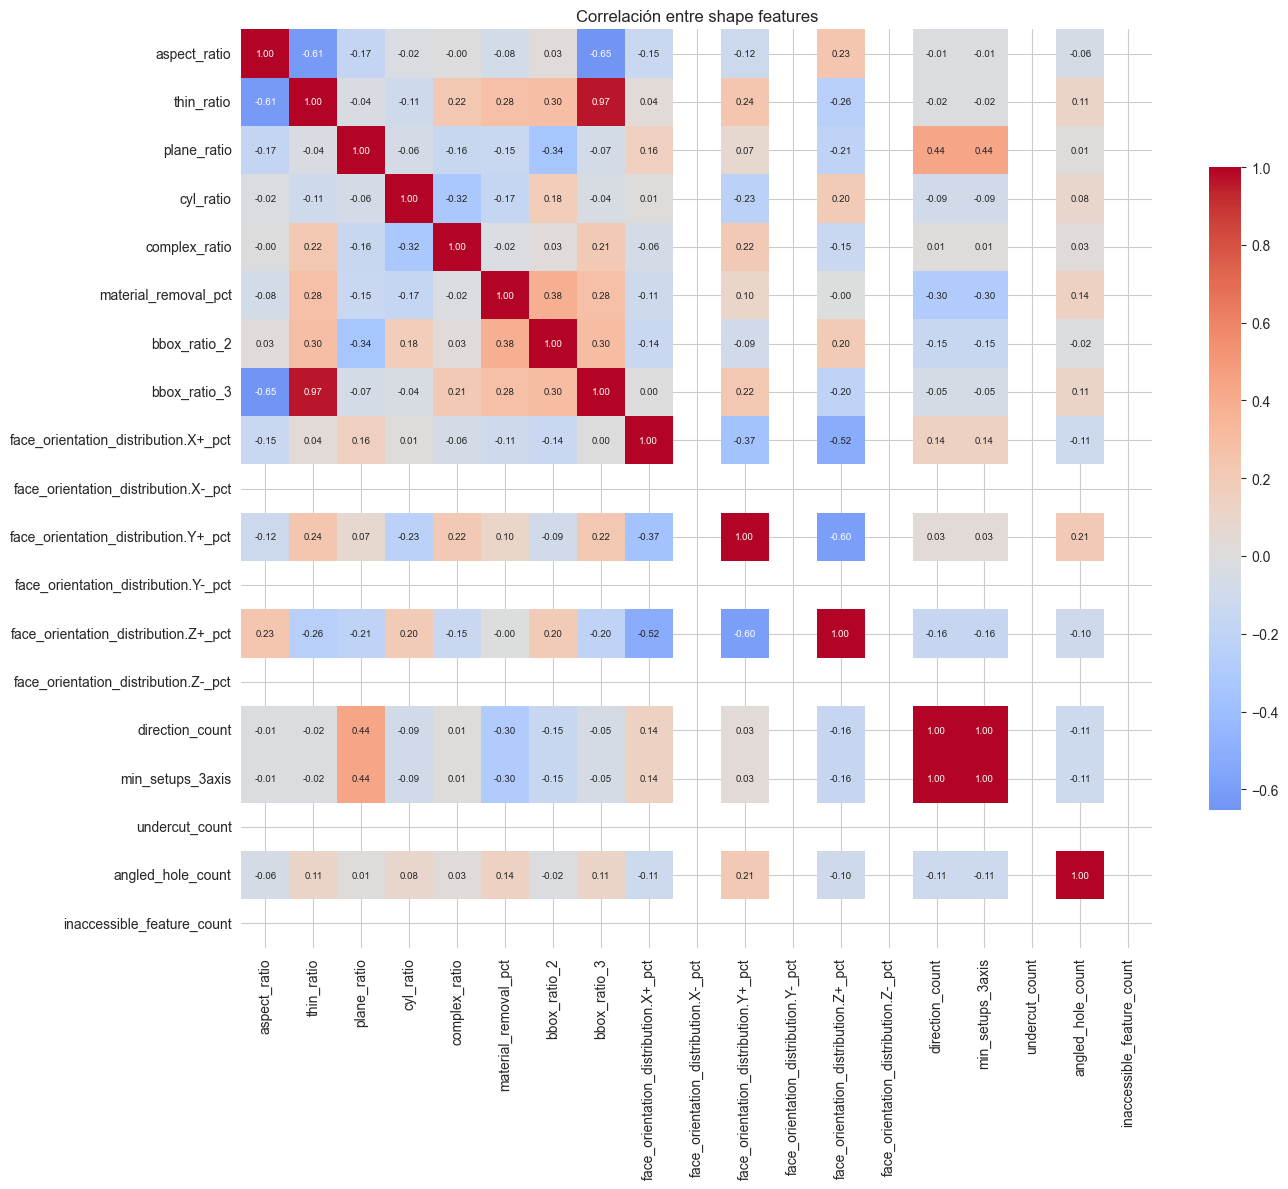

In [21]:
corr = df_dfm[SHAPE_FEATURES].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, ax=ax, cbar_kws={'shrink': .7})
ax.set_title('Correlación entre shape features')
plt.tight_layout()
plt.show()

In [22]:
corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(key=abs, ascending=False))
print('Pares de shape features con |corr| > 0.8:')
print(corr_pairs[corr_pairs.abs() > 0.8].to_string())

Pares de shape features con |corr| > 0.8:
direction_count  min_setups_3axis    1.000000
thin_ratio       bbox_ratio_3        0.967091


## 8. Shape features ↔ precio unitario (sanity check)

Si la forma es informativa del costo, deberíamos ver correlaciones no triviales. Si no las hay, el tamaño y el material van a dominar la varianza del precio — el clustering de forma seguirá siendo útil como segmentación, pero para predicción de costo necesitaremos sí o sí incluir esas variables en la fase 2.

c:\python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlación shape features ↔ log(unit_price):
cyl_ratio                               0.246172
material_removal_pct                   -0.231089
bbox_ratio_3                           -0.184887
thin_ratio                             -0.168076
face_orientation_distribution.Y+_pct   -0.164395
complex_ratio                          -0.161313
face_orientation_distribution.Z+_pct    0.150962
direction_count                         0.131873
min_setups_3axis                        0.131873
angled_hole_count                       0.112733
aspect_ratio                            0.064488
plane_ratio                            -0.060922
bbox_ratio_2                           -0.011506
face_orientation_distribution.X+_pct    0.000620
face_orientation_distribution.X-_pct         NaN
face_orientation_distribution.Y-_pct         NaN
face_orientation_distribution.Z-_pct         NaN
undercut_count                               NaN
inaccessible_feature_count                   NaN


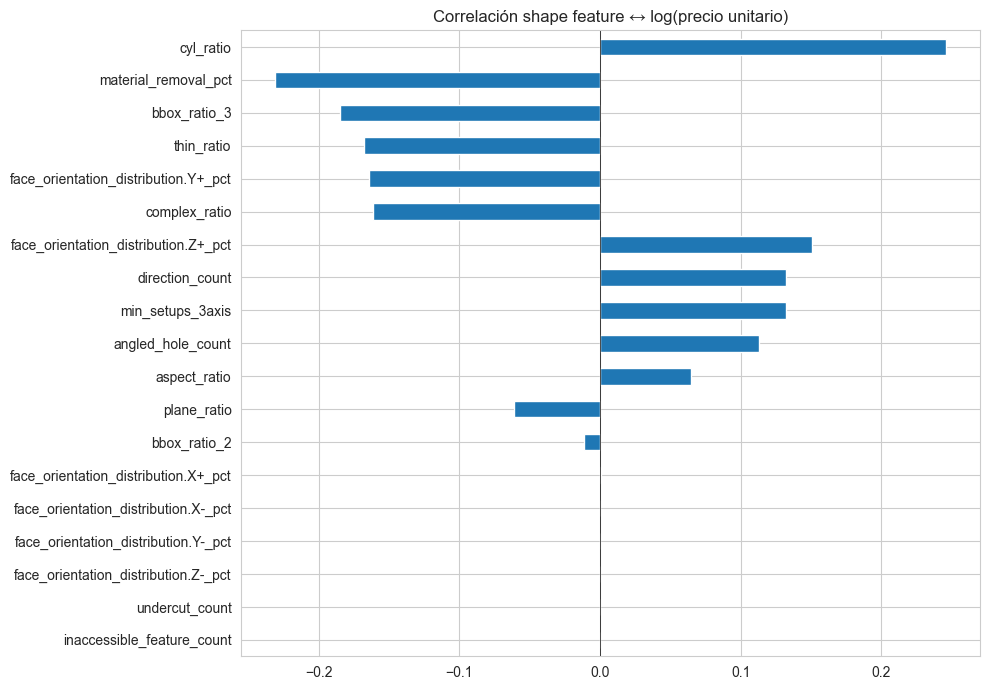

In [23]:
log_price = np.log1p(df_dfm['unit_price'])
corr_with_price = {}
for col in SHAPE_FEATURES:
    x = df_dfm[col]
    mask = x.notna() & log_price.notna()
    if mask.sum() > 10:
        corr_with_price[col] = np.corrcoef(x[mask], log_price[mask])[0, 1]

corr_series = pd.Series(corr_with_price).sort_values(key=abs, ascending=False)
print('Correlación shape features ↔ log(unit_price):')
print(corr_series.to_string())

fig, ax = plt.subplots(figsize=(10, 7))
corr_series.plot(kind='barh', ax=ax)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('Correlación shape feature ↔ log(precio unitario)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Guardar dataset limpio

Guardamos shape features + categóricas de forma + columnas auxiliares (ids, precio, tamaño) para las fases siguientes.

In [24]:
AUX_COLS = [
    'manufacturing_quote_id', 'line_item_id', 'radii_id', 'product_name',
    'actual_partner_quoted_price', 'actual_partner_quoted_quantity', 'unit_price',
    'partner_name', 'partner_country', 'quote_is_awarded',
    'material_title', 'technology', 'tolerance_tier', 'finishing', 'heat_treatment',
]

KEEP = AUX_COLS + SHAPE_FEATURES + CATEGORICAL_SHAPE + SIZE_FEATURES
KEEP = [c for c in KEEP if c in df_dfm.columns]
# Dedup manteniendo orden
seen = set()
KEEP = [c for c in KEEP if not (c in seen or seen.add(c))]

df_clean = df_dfm[KEEP].copy()
print(f'Dataset final: {df_clean.shape}')

df_clean.to_parquet('manufacturing_quotes_clean.parquet', index=False)
df_clean.to_csv('manufacturing_quotes_clean.csv', index=False)
print('Guardado: manufacturing_quotes_clean.parquet + .csv')

# Guardamos también la lista de shape features para que el notebook de clustering la importe
import json
with open('shape_features.json', 'w') as f:
    json.dump({
        'shape_features': SHAPE_FEATURES,
        'categorical_shape': CATEGORICAL_SHAPE,
        'size_features': SIZE_FEATURES,
        'aux_cols': AUX_COLS,
    }, f, indent=2)
print('Guardado: shape_features.json')

Dataset final: (297, 46)
Guardado: manufacturing_quotes_clean.parquet + .csv
Guardado: shape_features.json


## Hallazgos a revisar (llenar tras correr)

- [ ] # filas con DFM completo
- [ ] Shape features con skew fuerte o outliers
- [ ] Pares redundantes (|corr| > 0.8) → candidatos a descartar en clustering
- [ ] Shape features que más correlacionan con precio
- [ ] ¿`axis_recommendation` y `min_setups_3axis` están muy correlacionados? (probablemente sí)
- [ ] ¿Hay part_types con <10 piezas? → considerar agrupar en "other"

**Siguiente paso:** `02_clustering.ipynb` — escalado (StandardScaler sobre shape_features + one-hot sobre categoricals), UMAP 2D, HDBSCAN para part families, inspección manual de clusters.